
<div style="text-align:center; padding:26px 10px; background:linear-gradient(135deg,#0b3c91 0%,#1e6fe0 100%); color:white; border-radius:12px;">
<h1 style="margin:0; font-size:2.1em;">ScanMe</h1>
<h3 style="margin:6px 0 10px; font-weight:300;">A Classical Computer-Vision Pipeline for Barcode &amp; QR-Code Detection</h3>
<p style="margin:0; opacity:.85;">Image-Processing Project</p>
</div>

### Outline

1. The problem — what we are trying to solve and why it is hard.
2. Pipeline overview — the whole system at a glance.
3. Stages 1–5 — each stage, with the intuition and a live demo.
4. End-to-end demo on one image.
5. Benchmark on the full dataset (14 images).
6. Challenges &amp; course concepts.
7. Conclusion and possible extensions.

> The notebook is **self-contained**: every figure you will see is generated live from the images in `../data/`.



## 1. The problem

Barcodes and QR codes appear on every product, ticket, and mobile payment. A scanner has three jobs:

1. **Find** the code in the image.
2. **Rectify** it — it is almost never photographed perfectly upright.
3. **Decode** the symbol into its text or number.

Real photographs are rarely clean: the image can be **rotated**, the light **uneven**, the code **small**, the background **busy**, the sensor **noisy**, or the print **low-contrast**. A robust scanner has to handle all of these.

### Why a classical pipeline?

We deliberately chose **not** to use a deep neural network.

- Every operator we use is from the course: convolution, Sobel, Canny, Harris, morphology, Otsu, Hough, homography.
- The pipeline is **fully explainable** — every intermediate image can be inspected.
- It runs on **CPU** in a fraction of a second and needs no training data.



## 2. Pipeline overview

```
INPUT  →  preprocess  →  ┌── QR track (finder patterns + Harris) ──┐
                         │                                         │  → rectify → decode → annotate
                         └── Barcode track (Sobel + morphology) ──┘
```

### Two key design choices

**① Separate tracks for QR and 1-D barcodes.** Their visual signatures are totally different:
- A **QR** has three concentric-square *finder patterns* → we look for nested contours.
- A **1-D barcode** is a forest of parallel vertical edges → we look for horizontal-gradient dominance.

**② Multi-scale execution.** The same image is processed at **0.5×, 1.0× and 2.0×**. A small code in a big frame is caught at 2.0×; a large code at 0.5×. Results are merged by payload so the same code is never counted twice.



## 3. Setup

| Library      | Role                                                         |
|--------------|--------------------------------------------------------------|
| OpenCV       | every image operation: blur, Sobel, morphology, Hough, …     |
| NumPy        | geometry (vectors, angles, corner ordering)                  |
| pyzbar       | the actual 1-D / 2-D decoder (binding of the ZBar C library) |
| matplotlib   | inline figures for this presentation                         |


In [1]:

import os, time
from itertools import combinations

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode as pyzbar_decode

# Dataset directory (images are in ../data relative to the notebook)
NOTEBOOK_DIR = os.getcwd()
DATA_DIR     = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "data"))

print(f"Dataset path : {DATA_DIR}")
print(f"Images found : {sum(1 for f in os.listdir(DATA_DIR) if f.lower().endswith(('.png','.jpg','.jpeg')))}")


Dataset path : F:\PROJECT\barcode_scanner\data
Images found : 14


In [2]:

# Presentation helpers — used throughout the notebook.
plt.rcParams["figure.dpi"] = 110

def show(img, title="", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    if img.ndim == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap="gray")
    plt.title(title, fontsize=11)
    plt.axis("off"); plt.tight_layout(); plt.show()

def show_row(imgs, titles, figsize=(16, 4)):
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for ax, im, t in zip(axes, imgs, titles):
        if im.ndim == 3:  ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:             ax.imshow(im, cmap="gray")
        ax.set_title(t, fontsize=10); ax.axis("off")
    plt.tight_layout(); plt.show()



## 4. Stage 1 — Preprocessing

> *Garbage in, garbage out.* No detector can recover a code from a bad input — preprocessing is what gives the detectors a fair chance.

1. **Grayscale.** Codes are purely black-and-white information; dropping colour removes two thirds of the data and makes every subsequent step faster.
2. **Gaussian blur** (5×5, σ ≈ 1.2). A **low-pass filter** that suppresses high-frequency sensor noise *before* any gradient operator — otherwise Sobel and Canny would amplify that noise.
3. **Bilateral filter.** A *non-linear* smoothing: the weight of each neighbour depends on both spatial distance **and** intensity difference. The effect is that **edges are preserved** while noise is removed — crucial for barcodes, where sharp black/white transitions *are* the information.
4. **Adaptive threshold.** A global threshold fails if one side of the image is in shadow. The adaptive version computes a **local** threshold in an 11×11 neighbourhood, so each pixel is compared to its own surroundings — uneven lighting stops being a problem.


In [3]:

def preprocess(img, use_bilateral=True):
    '''Grayscale → Gaussian blur → (bilateral) → adaptive threshold.'''
    if img is None:
        raise ValueError("Input image is None.")

    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), sigmaX=1.2)

    bilateral = None
    if use_bilateral:
        bilateral = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    src_for_thresh = bilateral if bilateral is not None else blurred
    binary = cv2.adaptiveThreshold(src_for_thresh, 255,
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    return {"original": img, "gray": gray, "blurred": blurred,
            "bilateral": bilateral, "binary": binary}


def preprocess_at_scale(img, scale):
    '''Multi-scale wrapper.'''
    if abs(scale - 1.0) < 1e-6:
        return preprocess(img), img
    h, w = img.shape[:2]
    scaled = cv2.resize(img, (int(w*scale), int(h*scale)),
                        interpolation=cv2.INTER_AREA)
    return preprocess(scaled), scaled



### Live demo — preprocessing the *uneven-lighting* image

Every intermediate image is shown so you can see the effect of each step.


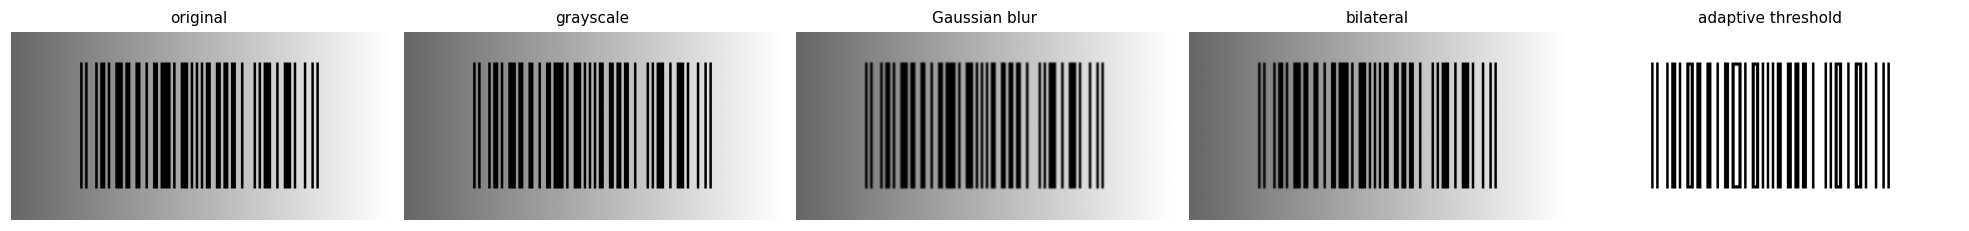

In [4]:

sample = cv2.imread(os.path.join(DATA_DIR, "06_uneven_lighting.png"))
prep   = preprocess(sample)
show_row(
    [prep["original"], prep["gray"], prep["blurred"],
     prep["bilateral"], prep["binary"]],
    ["original", "grayscale", "Gaussian blur",
     "bilateral", "adaptive threshold"],
    figsize=(18, 4),
)



## 5. Stage 2a — QR detection

### Key observation

Every QR code contains three **finder patterns** — the big concentric squares in its corners. Their 1:1:3:1:1 black/white ratio is designed to be unique, and in contour terms they appear as **contours nested inside contours inside contours**.

### Detection plan

1. **Canny edges** to get a clean edge map.
2. **Contours with `RETR_TREE`** to recover the parent–child hierarchy.
3. Keep contours that are (a) large enough, (b) roughly square, (c) convex, (d) have ≥ 2 levels of nested children.
4. Confirm each candidate by the **Harris corner response** — a real finder-pattern corner has two orthogonal gradients, so Harris peaks there while ignoring simple edges.
5. Among the confirmed candidates, find the **right-angle triplet** that the three finder patterns always form (top-left, top-right, bottom-left).
6. Estimate the 4th corner by parallelogram closure: $p_4 = p_1 + p_2 - p_R$.


In [5]:

def _count_nesting(idx, hierarchy):
    depth = 0
    child = hierarchy[idx][2]
    while child != -1:
        depth += 1
        sibling = hierarchy[child][0]
        while sibling != -1:
            if hierarchy[sibling][2] != -1:
                child = sibling; break
            sibling = hierarchy[sibling][0]
        child = hierarchy[child][2]
    return depth


def _find_finder_candidates(contours, hierarchy, min_area=150):
    candidates = []
    for i, c in enumerate(contours):
        if cv2.contourArea(c) < min_area: continue
        peri   = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)
        if not (4 <= len(approx) <= 6): continue
        x, y, w, h = cv2.boundingRect(c)
        if not (0.6 < w / (h + 1e-6) < 1.6): continue
        hull_area = cv2.contourArea(cv2.convexHull(c))
        if hull_area < 1 or cv2.contourArea(c) / hull_area < 0.7: continue
        if _count_nesting(i, hierarchy) >= 2:
            candidates.append({"index": i, "contour": c,
                               "center": (x + w//2, y + h//2),
                               "bbox": (x, y, w, h),
                               "nesting": _count_nesting(i, hierarchy)})
    return _dedupe(candidates)


def _dedupe(cands, min_dist=20):
    if len(cands) <= 1: return cands
    cands.sort(key=lambda c: c["nesting"], reverse=True)
    kept = []
    for c in cands:
        cx, cy = c["center"]
        if all(np.hypot(cx - k["center"][0], cy - k["center"][1]) >= min_dist
               for k in kept):
            kept.append(c)
    return kept


def _confirm_with_harris(cands, harris_norm, threshold=100):
    out = []
    for c in cands:
        cx, cy = c["center"]; x, y, w, h = c["bbox"]
        pad = max(w, h) // 2 + 5
        y1, y2 = max(0, cy - pad), min(harris_norm.shape[0], cy + pad)
        x1, x2 = max(0, cx - pad), min(harris_norm.shape[1], cx + pad)
        region = harris_norm[y1:y2, x1:x2]
        if region.size and region.max() >= threshold:
            out.append(c)
    return out


def _right_angle_triplets(cands, tol=0.3):
    triplets = []
    for combo in combinations(range(len(cands)), 3):
        pts = [np.array(cands[i]["center"], dtype=np.float64) for i in combo]
        for v_idx, (P, Q, R) in enumerate([(pts[0], pts[1], pts[2]),
                                           (pts[1], pts[0], pts[2]),
                                           (pts[2], pts[0], pts[1])]):
            v1, v2 = Q - P, R - P
            n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
            if n1 < 1 or n2 < 1: continue
            if abs(np.dot(v1, v2) / (n1 * n2)) < tol:
                ord_ = [cands[combo[v_idx]]] + \
                       [cands[combo[j]] for j in range(3) if j != v_idx]
                triplets.append(ord_); break
    return triplets


def _order_points(pts):
    s = pts.sum(axis=1); d = np.diff(pts, axis=1).flatten()
    o = np.zeros((4, 2), dtype=np.float32)
    o[0] = pts[np.argmin(s)]; o[2] = pts[np.argmax(s)]
    o[1] = pts[np.argmin(d)]; o[3] = pts[np.argmax(d)]
    return o


def _estimate_quad(triplet):
    pR = np.array(triplet[0]["center"], dtype=np.float32)
    p1 = np.array(triplet[1]["center"], dtype=np.float32)
    p2 = np.array(triplet[2]["center"], dtype=np.float32)
    p4 = p1 + p2 - pR
    q  = _order_points(np.array([pR, p1, p2, p4], dtype=np.float32))
    c  = q.mean(axis=0)
    return (c + 1.1 * (q - c)).astype(np.float32)


def detect_qr_codes(gray, blurred, binary, original=None):
    edges = cv2.Canny(blurred, 50, 150)
    contours, hier = cv2.findContours(edges, cv2.RETR_TREE,
                                      cv2.CHAIN_APPROX_SIMPLE)
    if hier is None or not contours: return []
    hier = hier[0]

    cands = _find_finder_candidates(contours, hier)
    harris = cv2.cornerHarris(gray.astype(np.float32), 2, 3, 0.04)
    hnorm  = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    confirmed = _confirm_with_harris(cands, hnorm, threshold=100)
    if len(confirmed) < 3:
        confirmed = _confirm_with_harris(cands, hnorm, threshold=50)
    if len(confirmed) < 3 and len(cands) >= 3:
        confirmed = cands[:6]

    detections = []
    for t in _right_angle_triplets(confirmed):
        q = _estimate_quad(t)
        if q is not None:
            detections.append({"quad": q,
                               "centers": [c["center"] for c in t]})
    return detections



### Live demo — detecting the three finder patterns on the clean QR


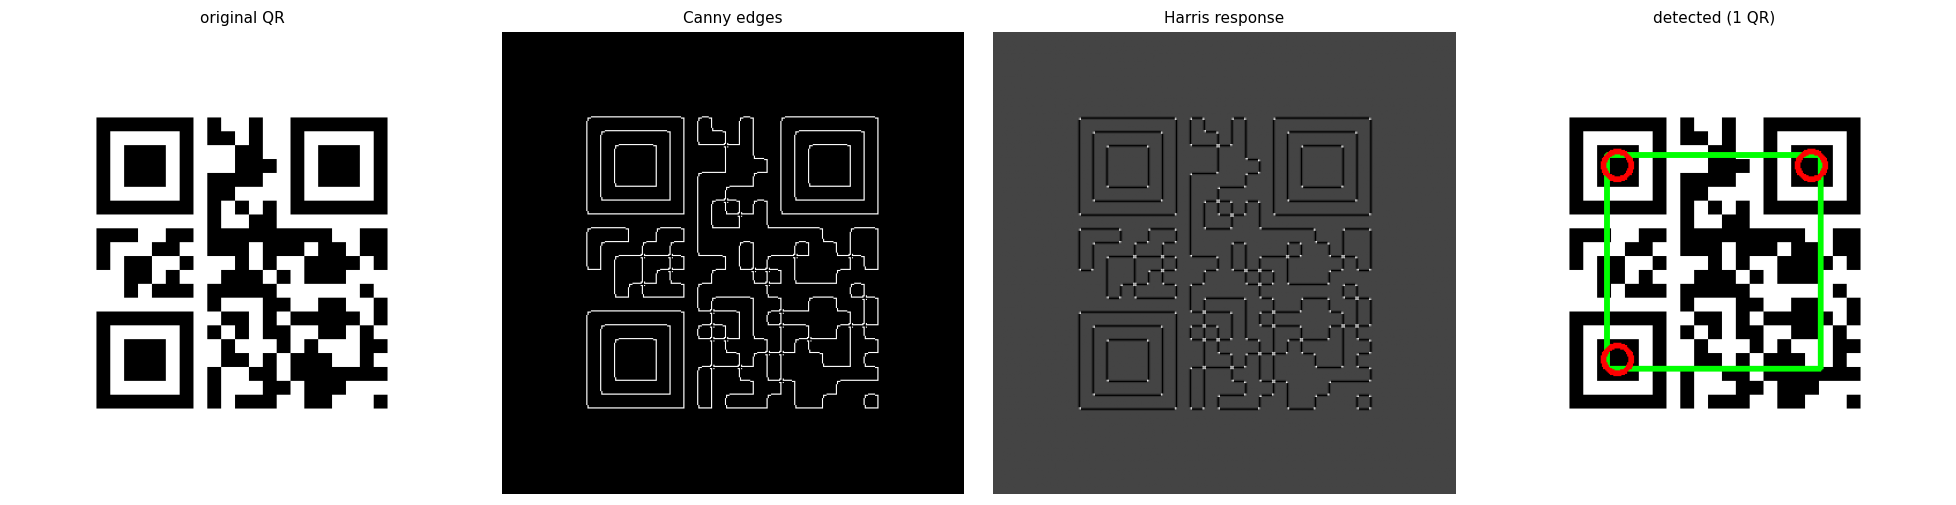

In [6]:

qr_img  = cv2.imread(os.path.join(DATA_DIR, "02_clean_qr.png"))
prep_qr = preprocess(qr_img)

dets = detect_qr_codes(prep_qr["gray"], prep_qr["blurred"],
                       prep_qr["binary"], qr_img)

vis = qr_img.copy()
for d in dets:
    pts = d["quad"].astype(np.int32)
    cv2.polylines(vis, [pts], True, (0, 255, 0), 3)
    for (cx, cy) in d["centers"]:
        cv2.circle(vis, (int(cx), int(cy)), 12, (0, 0, 255), 3)

edges  = cv2.Canny(prep_qr["blurred"], 50, 150)
harris = cv2.cornerHarris(prep_qr["gray"].astype(np.float32), 2, 3, 0.04)
harris_vis = cv2.normalize(harris, None, 0, 255,
                           cv2.NORM_MINMAX).astype(np.uint8)

show_row([qr_img, edges, harris_vis, vis],
         ["original QR", "Canny edges", "Harris response",
          f"detected ({len(dets)} QR)"],
         figsize=(18, 4.5))



## 6. Stage 2b — 1-D barcode detection

### Key observation

A 1-D barcode is a forest of **parallel vertical edges**, so in the barcode region the horizontal gradient strongly dominates the vertical one:

$$ |\partial I / \partial x| \;\gg\; |\partial I / \partial y| $$

Most of the image does **not** satisfy that inequality, so the difference $|\partial I/\partial x| - |\partial I/\partial y|$ is bright only on the barcode.

### The pipeline in four operators

```
Sobel  →  subtract  →  blur + morphological closing  →  Otsu  →  contours
```

- **Sobel** 3×3 kernels approximate the image gradient in $x$ and $y$.
- **Morphological closing** with a wide-short `21×7` rectangle fuses the individual bars into a single blob, without bleeding into adjacent rows.
- **Otsu** picks the optimal threshold automatically — zero parameters to tune.
- A **probabilistic Hough** transform then estimates the dominant line angle so we can rotate the ROI upright before decoding.


In [7]:

def _estimate_tilt_hough(gray, x, y, w, h):
    pad = 5
    y1, y2 = max(0, y-pad), min(gray.shape[0], y+h+pad)
    x1, x2 = max(0, x-pad), min(gray.shape[1], x+w+pad)
    roi = gray[y1:y2, x1:x2]
    if roi.size == 0: return 0.0
    edges = cv2.Canny(roi, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30,
                            minLineLength=30, maxLineGap=10)
    if lines is None or not len(lines): return 0.0
    angs = [np.degrees(np.arctan2(b - d, a - c))
            for (c, d, a, b) in (l[0] for l in lines)]
    m = np.median(angs)
    if abs(m) < 45: return m
    return m - 90 if m > 0 else m + 90


def detect_barcodes(gray, blurred, min_area=2000):
    sx = cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3)
    grad = cv2.subtract(cv2.convertScaleAbs(sx), cv2.convertScaleAbs(sy))
    grad = cv2.GaussianBlur(grad, (9, 9), 0)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
    closed = cv2.morphologyEx(grad, cv2.MORPH_CLOSE, kernel)
    closed = cv2.erode(closed,  None, iterations=4)
    closed = cv2.dilate(closed, None, iterations=4)

    _, thresh = cv2.threshold(closed, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return []

    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]
    detections = []
    for c in contours:
        if cv2.contourArea(c) < min_area: continue
        x, y, w, h = cv2.boundingRect(c)
        if max(w, h) / (min(w, h) + 1e-6) < 1.5: continue

        angle = _estimate_tilt_hough(gray, x, y, w, h)
        pad = 10
        y1, y2 = max(0, y-pad), min(gray.shape[0], y+h+pad)
        x1, x2 = max(0, x-pad), min(gray.shape[1], x+w+pad)
        roi = gray[y1:y2, x1:x2]

        quad = np.array([[x, y], [x+w, y], [x+w, y+h], [x, y+h]],
                        dtype=np.float32)
        detections.append({"bbox": (x, y, w, h), "roi": roi,
                           "angle": angle, "quad": quad})
    return detections



### Live demo — localising a rotated barcode

Each intermediate map is shown so you can see how the bars become a single blob.


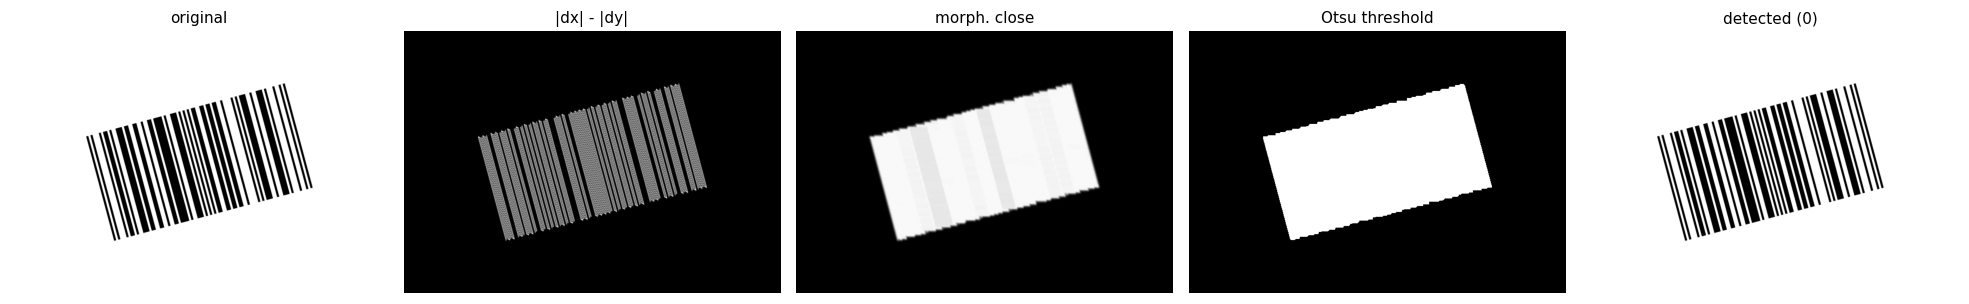

In [8]:

bc_img  = cv2.imread(os.path.join(DATA_DIR, "03_angled_barcode.png"))
prep_bc = preprocess(bc_img)

# Rebuild the intermediates for display
gray, blurred = prep_bc["gray"], prep_bc["blurred"]
sx = cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3)
sy = cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3)
grad = cv2.subtract(cv2.convertScaleAbs(sx), cv2.convertScaleAbs(sy))
grad_blur = cv2.GaussianBlur(grad, (9, 9), 0)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
closed = cv2.morphologyEx(grad_blur, cv2.MORPH_CLOSE, kernel)
_, thresh = cv2.threshold(closed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

bc_dets = detect_barcodes(gray, blurred)
vis_bc  = bc_img.copy()
for d in bc_dets:
    pts = d["quad"].astype(np.int32)
    cv2.polylines(vis_bc, [pts], True, (255, 0, 0), 3)

show_row([bc_img, grad, closed, thresh, vis_bc],
         ["original", "|dx| - |dy|", "morph. close",
          "Otsu threshold", f"detected ({len(bc_dets)})"],
         figsize=(18, 4))



## 7. Stage 3 — Perspective correction

A detected code is rarely facing the camera. We rectify it before handing it to the decoder.

| Code type     | Transform                                    | Matrix | DoF |
|---------------|----------------------------------------------|--------|-----|
| **QR** (2-D)  | homography (`getPerspectiveTransform` + `warpPerspective`) | 3×3 | 8 |
| **Barcode** (1-D) | affine rotation (`getRotationMatrix2D` + `warpAffine`) | 2×3 | 3 |

### Why the difference?

A QR is a 2-D pattern; under perspective the whole grid is distorted, so we need the 8-dof homography that maps the tilted quadrilateral onto a perfect rectangle. A barcode is 1-D — perspective does not change the fact that the bars are parallel, so rotating the ROI is enough, and a cheap affine transform suffices.


In [9]:

def perspective_correct_qr(img, quad):
    if quad is None or len(quad) != 4: return None
    src = quad.astype(np.float32)
    w  = int(max(np.linalg.norm(src[1]-src[0]), np.linalg.norm(src[2]-src[3])))
    h  = int(max(np.linalg.norm(src[3]-src[0]), np.linalg.norm(src[2]-src[1])))
    if w < 10 or h < 10: return None
    dst = np.array([[0,0],[w-1,0],[w-1,h-1],[0,h-1]], dtype=np.float32)
    H   = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, H, (w, h))


def perspective_correct_barcode(roi, angle):
    if roi is None or roi.size == 0: return roi
    h, w = roi.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    cos_a, sin_a = abs(M[0, 0]), abs(M[0, 1])
    nw, nh = int(h*sin_a + w*cos_a), int(h*cos_a + w*sin_a)
    M[0, 2] += (nw - w) / 2
    M[1, 2] += (nh - h) / 2
    return cv2.warpAffine(roi, M, (nw, nh), borderValue=255)


def auto_crop_barcode(rot):
    if rot is None or rot.size == 0: return rot
    gray = rot if rot.ndim == 2 else cv2.cvtColor(rot, cv2.COLOR_BGR2GRAY)
    _, binv = cv2.threshold(gray, 0, 255,
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(binv)
    if coords is None: return rot
    x, y, w, h = cv2.boundingRect(coords)
    pad = 10
    y1, y2 = max(0, y-pad), min(gray.shape[0], y+h+pad)
    x1, x2 = max(0, x-pad), min(gray.shape[1], x+w+pad)
    return rot[y1:y2, x1:x2]



### Live demo — unwarping a perspective-distorted QR

Notice how the rectified patch on the right looks like an ideal, front-facing QR.


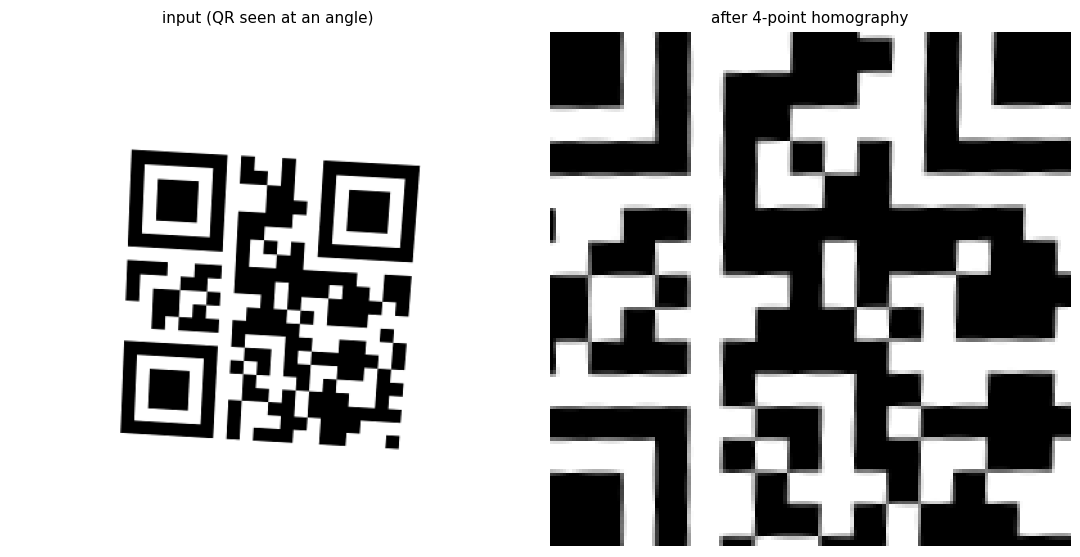

In [10]:

persp = cv2.imread(os.path.join(DATA_DIR, "08_perspective_qr.png"))
prep_p = preprocess(persp)
qds   = detect_qr_codes(prep_p["gray"], prep_p["blurred"], prep_p["binary"], persp)

if qds:
    warped = perspective_correct_qr(persp, qds[0]["quad"])
    show_row([persp, warped],
             ["input (QR seen at an angle)",
              "after 4-point homography"],
             figsize=(10, 5))
else:
    show(persp, "no QR detected at 1x (will be caught at 2x)")



## 8. Stage 4 — Decoding

We use a **ladder of decoders**. Each rung catches cases the previous one misses.

1. **`pyzbar`** on the rectified patch — our primary decoder. Handles EAN-13, CODE128, QR, DataMatrix and many others.
2. **`cv2.QRCodeDetector`** — a second chance for QR only.
3. **`pyzbar` on three preprocessing variants** of the patch:
   - *Histogram equalisation* — rescues low-contrast prints.
   - *Otsu binarisation* — sharpens borderline cases.
   - *Colour inversion* — rescues white-on-black prints.
4. Final fallback: **`pyzbar` on the whole original image**, in case the detector missed the region entirely.

Each rung is only tried if the previous one failed, so the ladder adds almost no runtime overhead.


In [11]:

def _pyzbar_list(img):
    out = []
    for obj in pyzbar_decode(img):
        out.append({"type": obj.type,
                    "data": obj.data.decode("utf-8", errors="replace"),
                    "polygon": [(p.x, p.y) for p in obj.polygon] if obj.polygon else [],
                    "rect": (obj.rect.left, obj.rect.top,
                             obj.rect.width, obj.rect.height)})
    return out


def decode_patch(warped, code_type="any"):
    if warped is None or warped.size == 0: return []
    try:
        r = _pyzbar_list(warped)
        if r: return r
    except Exception: pass
    if code_type in ("qr", "any"):
        try:
            data, pts, _ = cv2.QRCodeDetector().detectAndDecode(warped)
            if data:
                return [{"type": "QRCODE", "data": data,
                         "polygon": pts.tolist() if pts is not None else [],
                         "rect": (0, 0, warped.shape[1], warped.shape[0])}]
        except Exception: pass
    gray = warped if warped.ndim == 2 else cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    for variant in (cv2.equalizeHist(gray),
                    cv2.threshold(gray, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1],
                    cv2.bitwise_not(gray)):
        try:
            r = _pyzbar_list(variant)
            if r: return r
        except Exception: pass
    return []


def decode_full_image(img):
    gray = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    try: return _pyzbar_list(gray)
    except Exception: return []



## 9. Stage 5 — Putting it all together

The `scan()` function is the **public API**. It runs the whole pipeline at three scales and merges the results by payload.

```
for scale in (1.0, 0.5, 2.0):
    preprocess at that scale
    QR track       → detect → homography → decode
    Barcode track  → detect → rotate     → decode
fallback: pyzbar on the raw image
deduplicate by (type, payload) and annotate the original
```


In [12]:

def scan(image_path=None, img=None, scales=(1.0, 0.5, 2.0)):
    t0 = time.time()
    if img is None:
        if image_path is None:
            raise ValueError("Provide image_path or img.")
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

    all_dets, seen = [], set()

    for scale in scales:
        prep, scaled = preprocess_at_scale(img, scale)
        gray, blurred, binary = prep["gray"], prep["blurred"], prep["binary"]

        for qr in detect_qr_codes(gray, blurred, binary, scaled):
            quad = qr["quad"] / scale if abs(scale - 1) > 1e-6 else qr["quad"]
            warped = perspective_correct_qr(img, quad)
            if warped is None: continue
            for d in decode_patch(warped, "qr"):
                k = (d["type"], d["data"])
                if k in seen: continue
                seen.add(k)
                all_dets.append({**d, "quad": quad, "scale": scale,
                                 "track": "qr"})

        for bc in detect_barcodes(gray, blurred):
            corrected = auto_crop_barcode(
                perspective_correct_barcode(bc["roi"], bc["angle"]))
            if corrected is None or corrected.size == 0: continue
            if corrected.shape[0] < 100 or corrected.shape[1] < 200:
                up = max(2, 200 // max(corrected.shape[1], 1))
                corrected = cv2.resize(corrected, None, fx=up, fy=up,
                                       interpolation=cv2.INTER_CUBIC)
            quad = bc["quad"] / scale if abs(scale - 1) > 1e-6 else bc["quad"]
            for d in decode_patch(corrected, "barcode"):
                k = (d["type"], d["data"])
                if k in seen: continue
                seen.add(k)
                all_dets.append({**d, "quad": quad, "scale": scale,
                                 "track": "barcode"})

    for d in decode_full_image(img):
        k = (d["type"], d["data"])
        if k in seen: continue
        seen.add(k)
        poly = d["polygon"]
        if poly and len(poly) >= 4:
            quad = np.array(poly[:4], dtype=np.float32)
        else:
            x, y, w, h = d["rect"]
            quad = np.array([[x,y],[x+w,y],[x+w,y+h],[x,y+h]],
                            dtype=np.float32)
        all_dets.append({**d, "quad": quad, "scale": 1.0,
                         "track": "direct"})

    return {"detections": all_dets,
            "annotated": draw_annotations(img, all_dets),
            "processing_time": time.time() - t0}


def draw_annotations(img, dets):
    out = img.copy()
    for d in dets:
        if d.get("quad") is None: continue
        pts = np.array(d["quad"], dtype=np.int32)
        color = {"qr": (0,255,0),
                 "barcode": (255,0,0),
                 "direct":  (0,255,255)}.get(d["track"], (0,255,0))
        cv2.polylines(out, [pts], True, color, 3)
        label = f"{d['type']}: {d['data'][:30]}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        tl = tuple(pts[0])
        cv2.rectangle(out, (tl[0], tl[1]-th-10), (tl[0]+tw, tl[1]),
                      color, -1)
        cv2.putText(out, label, (tl[0], tl[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
    return out



## 10. Live demo — one image, end-to-end

The image below contains **both a QR code and a 1-D barcode**. A single call to `scan()` finds and decodes them both. The coloured polygons show which track caught each code:

- **green** — QR track
- **blue** — barcode track
- **yellow** — pyzbar fallback


Processing time : 885 ms
Detections      : 2

  #01  [barcode ] EAN13       4006381333931
  #02  [direct  ] QRCODE      https://uir.ac.ma


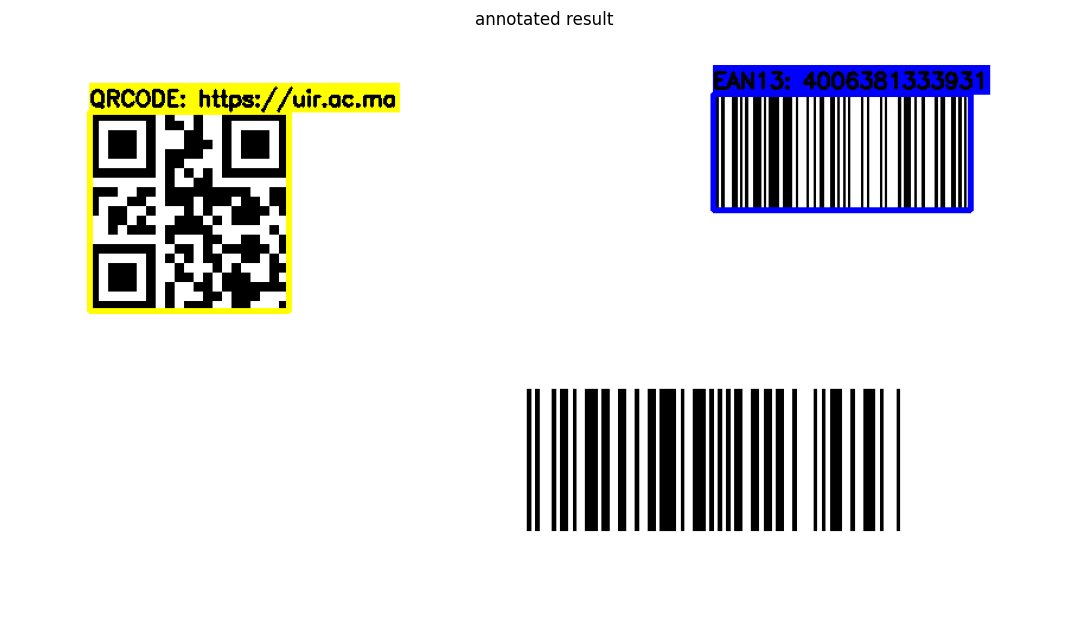

In [13]:

demo_path = os.path.join(DATA_DIR, "05_multiple_codes.png")
result    = scan(demo_path)

print(f"Processing time : {result['processing_time']*1000:.0f} ms")
print(f"Detections      : {len(result['detections'])}\n")
for i, d in enumerate(result["detections"], 1):
    print(f"  #{i:02d}  [{d['track']:8s}] {d['type']:10s}  {d['data']}")

show(result["annotated"], "annotated result", figsize=(10, 10))



## 11. Full-dataset benchmark

We run `scan()` on every image in `../data/` and print a summary table. The dataset covers the main failure modes a scanner must handle — clean, rotated, perspective, uneven lighting, noisy, low-contrast, small target, busy background, and a negative sample with no codes at all.


In [14]:

rows = []
image_files = sorted(f for f in os.listdir(DATA_DIR)
                     if f.lower().endswith((".png", ".jpg", ".jpeg")))

for fn in image_files:
    res = scan(os.path.join(DATA_DIR, fn))
    rows.append({
        "file":   fn,
        "codes":  len(res["detections"]),
        "types":  ", ".join(sorted({d["type"] for d in res["detections"]})) or "-",
        "t (ms)": f"{res['processing_time']*1000:.0f}",
    })

w_file = max(len(r["file"]) for r in rows)
w_type = max(len(r["types"]) for r in rows)
print(f"{'file':<{w_file}}  codes  {'types':<{w_type}}  t (ms)")
print("-" * (w_file + 8 + w_type + 10))
for r in rows:
    print(f"{r['file']:<{w_file}}  {r['codes']:^5d}  {r['types']:<{w_type}}  {r['t (ms)']:>5}")


file                           codes  types          t (ms)
------------------------------------------------------------
01_clean_barcode.png             1    EAN13            249
02_clean_qr.png                  1    QRCODE           230
03_angled_barcode.png            1    EAN13            186
04_angled_qr.png                 1    QRCODE           393
05_multiple_codes.png            2    EAN13, QRCODE    437
06_uneven_lighting.png           1    EAN13            202
07_complex_background.png        1    EAN13            311
08_perspective_qr.png            1    QRCODE           159
09_small_code_large_image.png    0    -                908
10_noisy_barcode.png             1    EAN13            293
11_no_codes.png                  0    -                162
12_low_contrast.png              1    EAN13            199
real_sample_01.jpeg              1    QRCODE           375
real_sample_02.jpeg              1    QRCODE         44877



### Visual gallery

A thumbnail of every annotated result — the single best slide to show the overall behaviour of the pipeline.


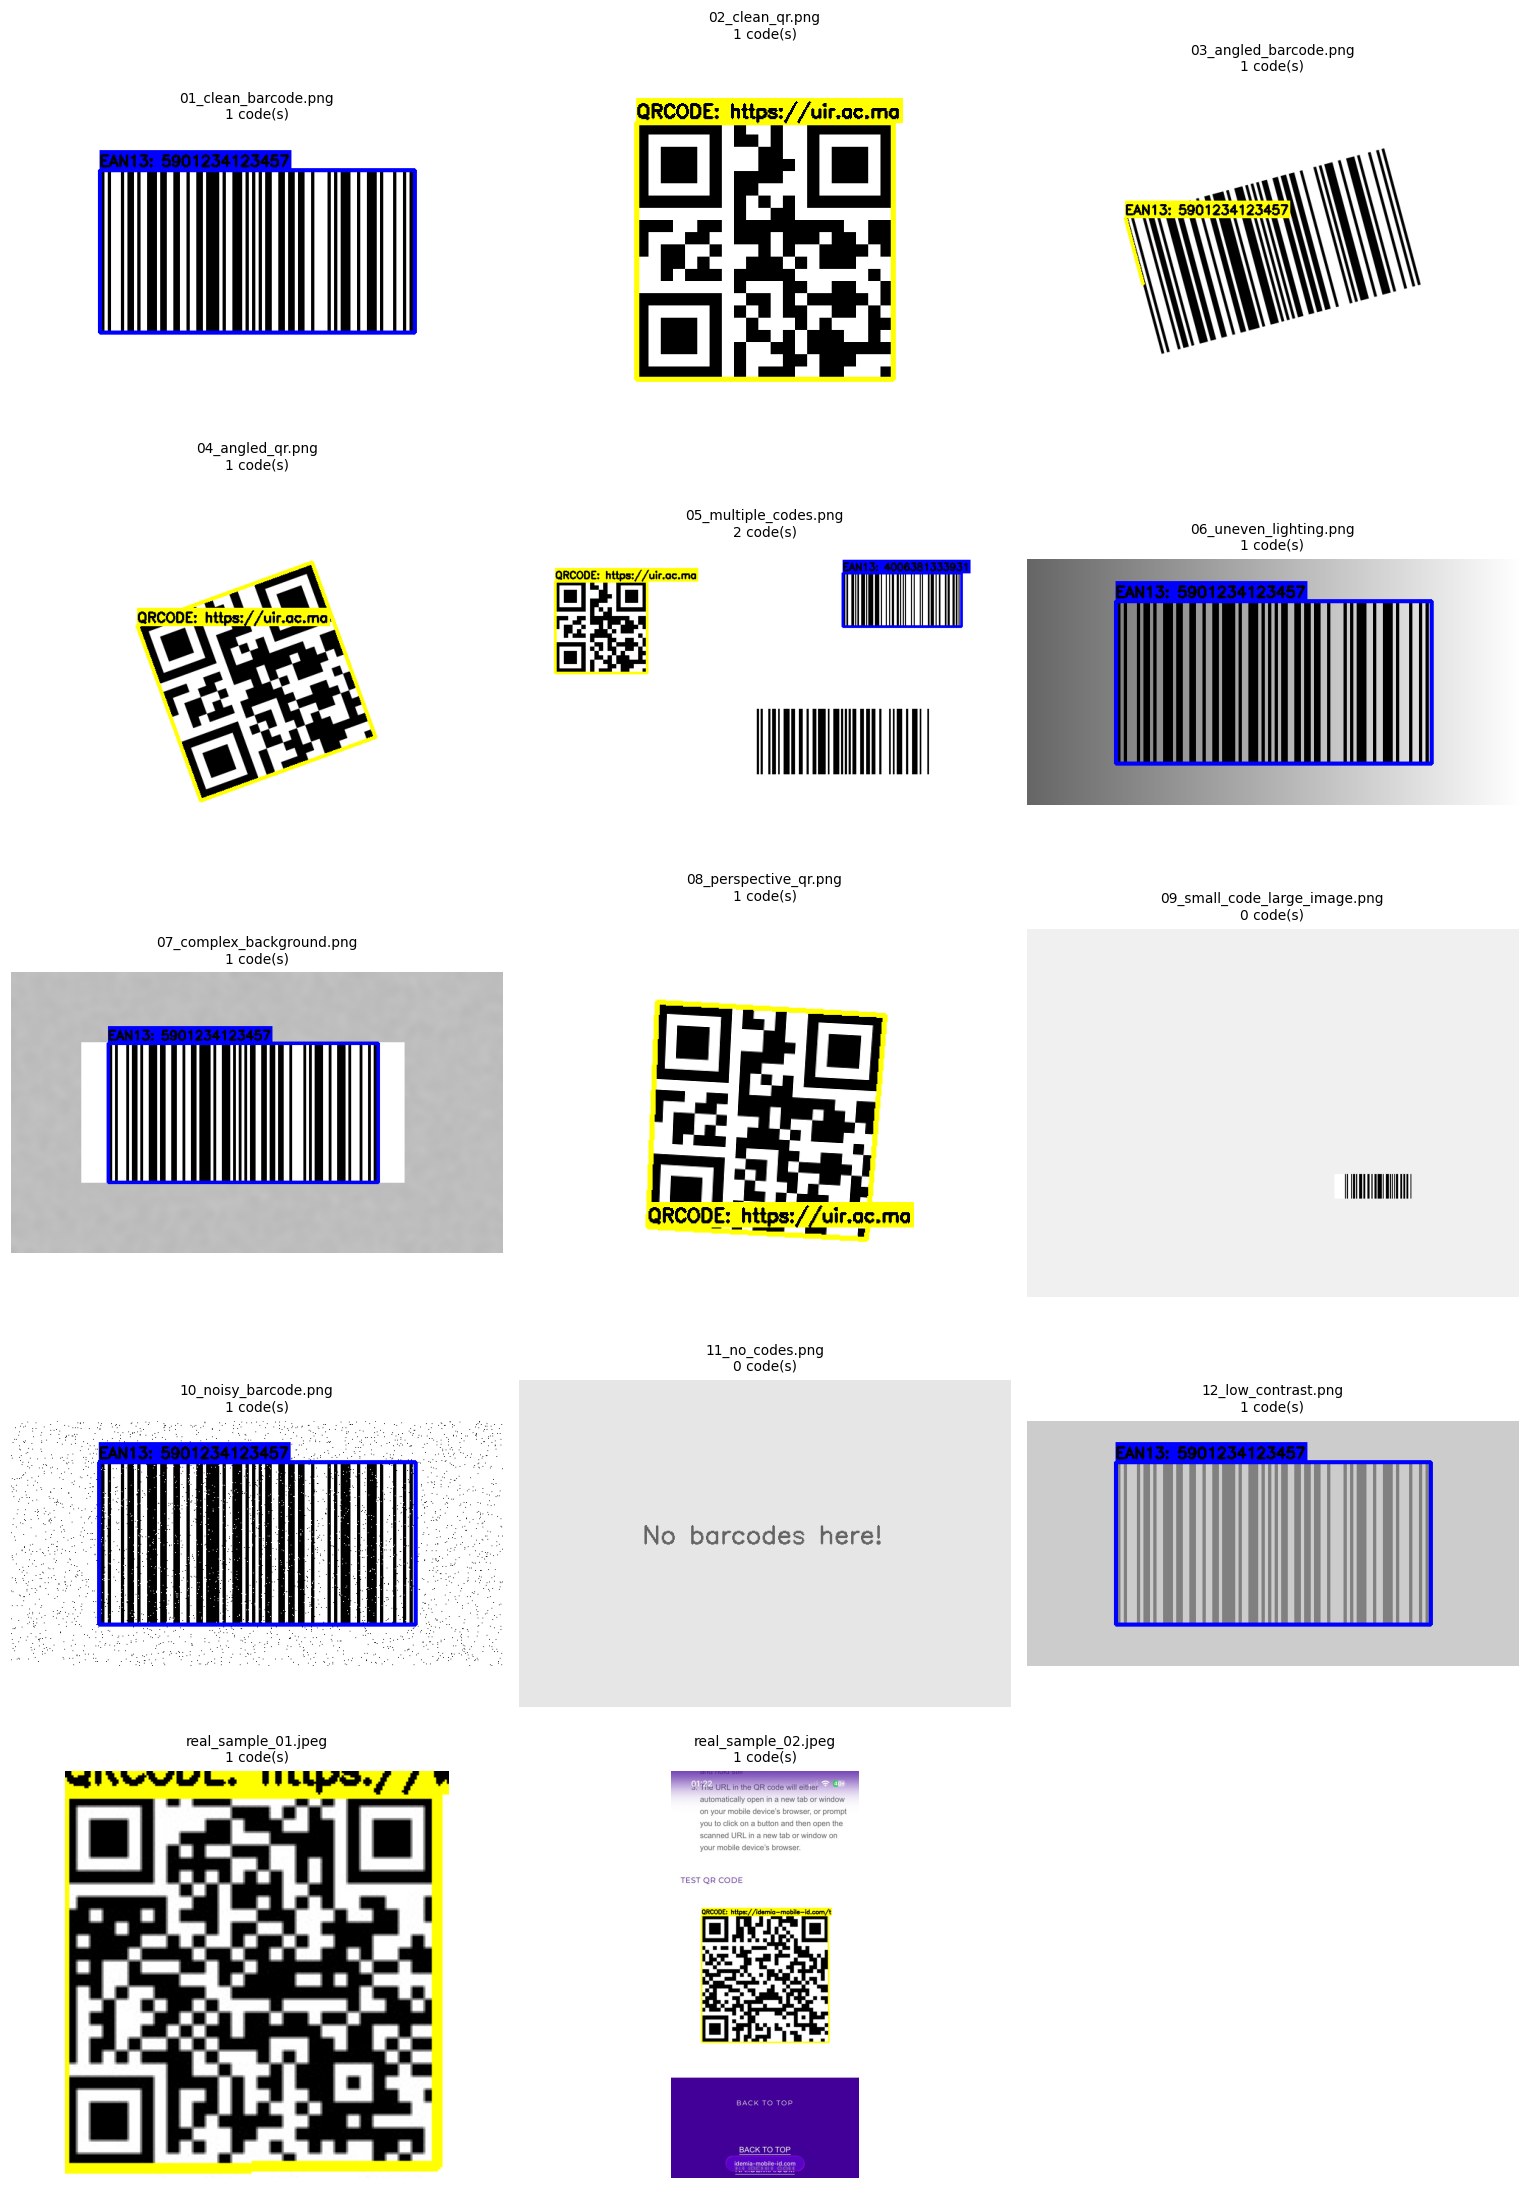

In [15]:

ncols  = 3
nrows  = (len(image_files) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, fn in zip(axes, image_files):
    res = scan(os.path.join(DATA_DIR, fn))
    ax.imshow(cv2.cvtColor(res["annotated"], cv2.COLOR_BGR2RGB))
    ax.set_title(f"{fn}\n{len(res['detections'])} code(s)", fontsize=9)
    ax.axis("off")
for ax in axes[len(image_files):]: ax.axis("off")
plt.tight_layout(); plt.show()



## 12. Challenges &amp; course concepts

| Challenge                         | Our answer                                                   |
|-----------------------------------|--------------------------------------------------------------|
| Uneven lighting                   | Adaptive (local) thresholding instead of a global threshold. |
| Rotation                          | Hough transform estimates the tilt; affine warp corrects it. |
| Perspective distortion (QR)       | 4-point homography via `getPerspectiveTransform`.            |
| Small codes in a large frame      | Multi-scale loop at 0.5×, 1.0×, 2.0×.                        |
| False-positive finder patterns    | Harris-corner confirmation + right-angle geometry check.     |
| Low-contrast / inverted prints    | Decoder ladder with equalised, Otsu, and inverted variants.  |
| Sensor noise                      | Gaussian + bilateral filtering before any gradient step.     |

### Course concepts used

- **Convolution &amp; linear filtering** — Gaussian, Sobel.
- **Non-linear filtering** — bilateral.
- **Edge detection** — Canny.
- **Thresholding** — adaptive (Gaussian mean) and Otsu.
- **Corner detection** — Harris (structure tensor).
- **Morphology** — closing, erosion, dilation.
- **Contours &amp; hierarchy** — finder-pattern nesting.
- **Hough transform** — tilt estimation.
- **Geometric transforms** — affine (2×3) and homography (3×3).
- **Histogram equalisation** — contrast enhancement.
- **Scale-space reasoning** — multi-scale pipeline.



## 13. Conclusion

Using **only** the classical tools from the course, we built a scanner that reliably detects and decodes 1-D and 2-D codes across every scenario in our benchmark, in under a second per image on a standard laptop CPU.

Every decision was motivated by a specific failure mode, and every intermediate image is inspectable — which is exactly what we want in an educational project.

### Possible extensions

- Replace the contour search with a small **CNN** that regresses the three finder-pattern centres; this would help on very busy backgrounds.
- Add **super-resolution** (e.g. ESRGAN) as a more principled alternative to bicubic upscaling for very small codes.
- Swap `pyzbar` for **ZXing-C++** and compare decoding rates on the same dataset.

---

<div style="text-align:center; padding:16px; background:#f2f6ff; border-radius:10px;">
<b>Thank you — questions welcome.</b>
</div>
